# Stage 1 — Data Preprocessing

Pipeline for both datasets:


1. Load - Read CSVs, inspect shape and dtypes |
2. Explore - Distributions, missing values, label balance |
3. Clean - Fix date ordering, handle saturation values |
4. Normalise - Min-max scale sensor features, save ranges |
5. Window Sliding - window helper for context assembly |
6. Export - Save cleaned CSVs for Stage 2 |

**Dataset**
- `ai4i2020.csv` — Industrial predictive maintenance, 10 000 rows, 5 labeled failure modes

In [1]:
import sys
import json
from pathlib import Path

sys.path.insert(0, str(Path('../')))

from src.preprocessing import (
    load_raw, clean, engineer_features, normalise, export,
    get_window,
    plot_label_distribution, plot_scatter_matrix, plot_correlations,
    SENSOR_COLS, ORIG_NAMES,
)

DATA_DIR = Path('../data')

In [2]:
# 1. LOAD
df_raw = load_raw(DATA_DIR / 'ai4i2020.csv')
df_raw.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [4]:
# 2. EXPLORE — missing values and stats
print('Missing values:', df_raw.isnull().sum().to_dict())
df_raw[ORIG_NAMES].describe().round(2)

Missing values: {'UDI': 0, 'Product ID': 0, 'Type': 0, 'Air temperature [K]': 0, 'Process temperature [K]': 0, 'Rotational speed [rpm]': 0, 'Torque [Nm]': 0, 'Tool wear [min]': 0, 'Machine failure': 0, 'TWF': 0, 'HDF': 0, 'PWF': 0, 'OSF': 0, 'RNF': 0}


,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min]
count,10000.0,10000.00,10000.00,10000.00,10000.00
mean,300.0,310.01,1538.78,39.99,107.95
std,2.0,1.48,179.28,9.97,63.65
min,295.3,305.70,1168.00,3.80,0.00
25%,298.3,308.80,1423.00,33.20,53.00
50%,300.1,310.10,1503.00,40.10,108.00
75%,301.5,311.10,1612.00,46.80,162.00
max,304.5,313.80,2886.00,76.60,253.00


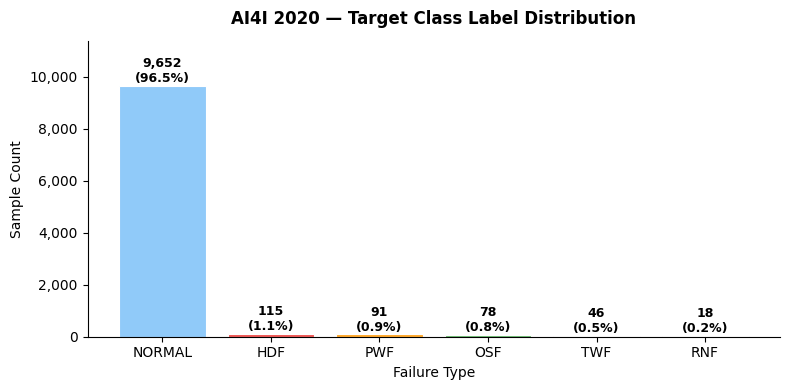

In [5]:
# 2. EXPLORE — failure_type class label distribution
plot_label_distribution(df_raw, DATA_DIR)

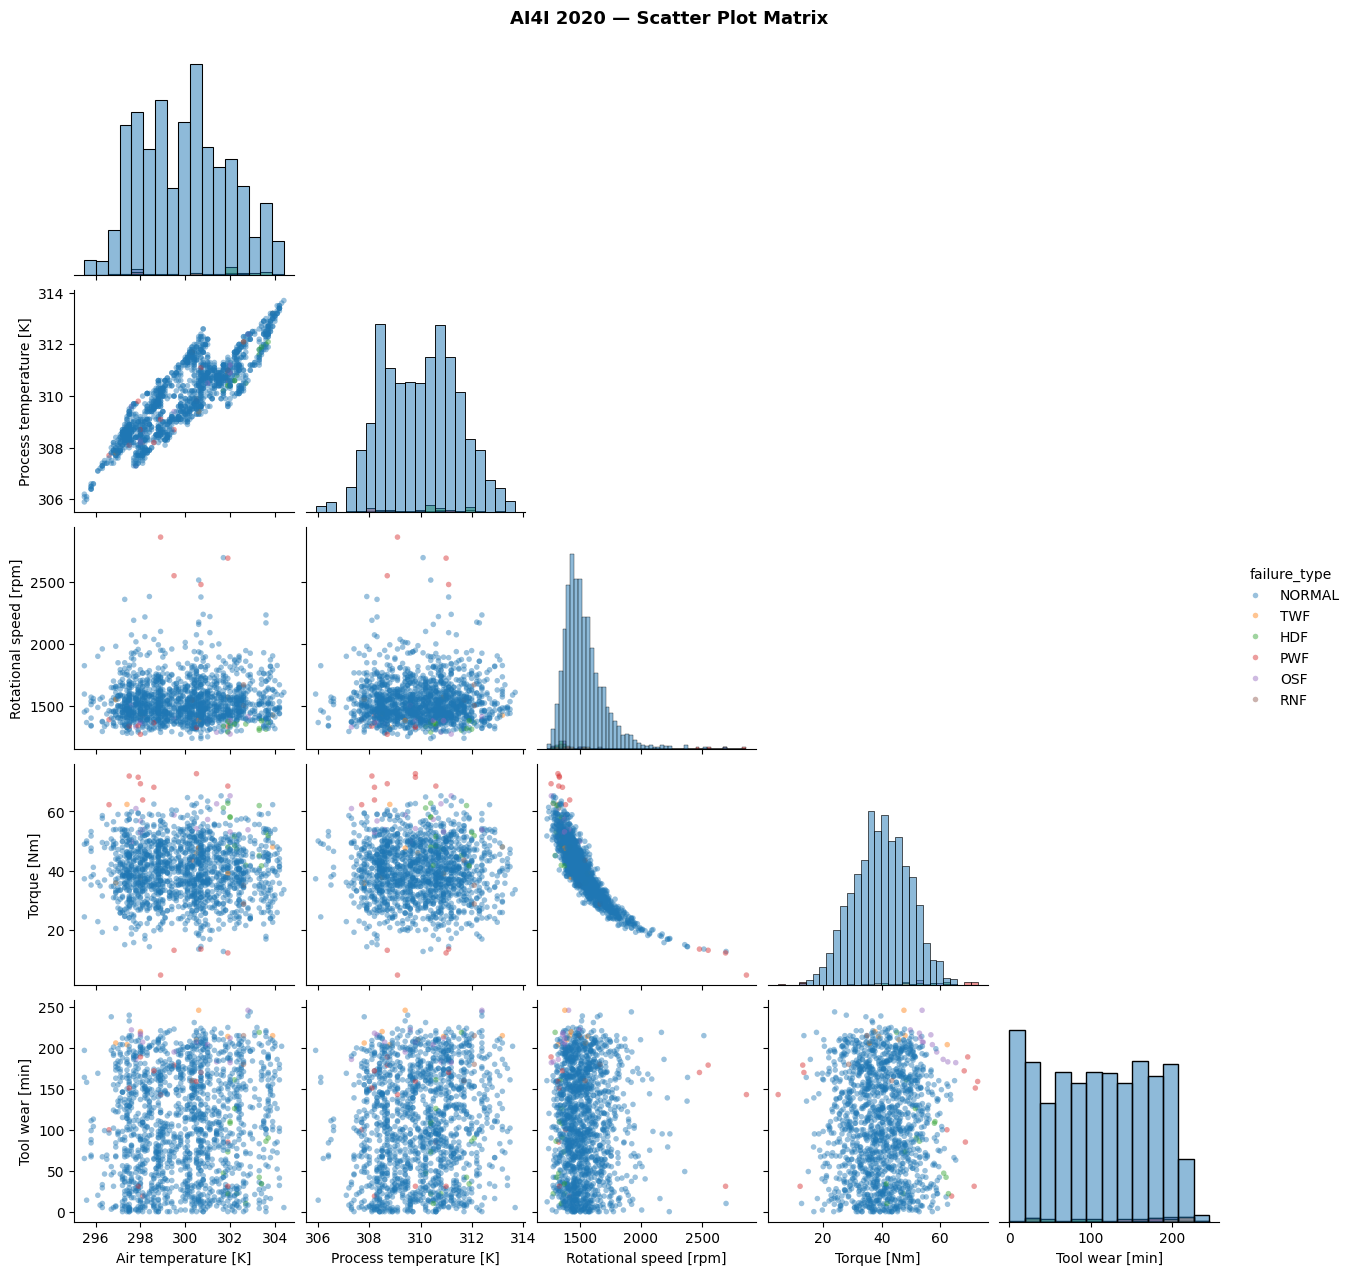

In [6]:
# 2. EXPLORE — scatter plot matrix
plot_scatter_matrix(df_raw, DATA_DIR)

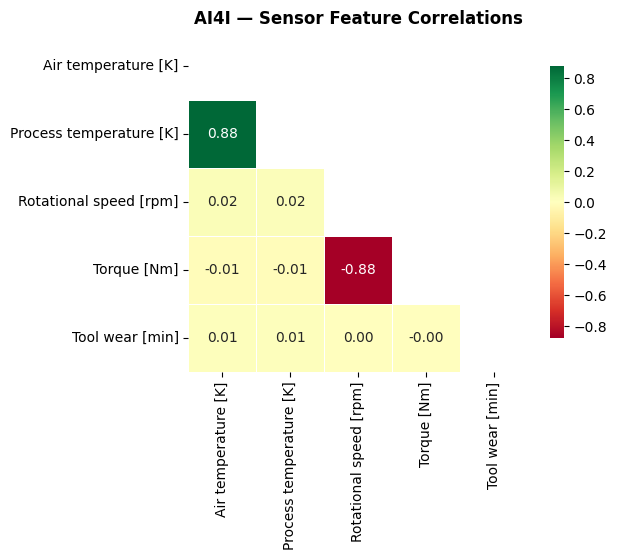

In [7]:
# 2. EXPLORE — correlations
plot_correlations(df_raw, DATA_DIR)

In [8]:
# 3. CLEAN
df_clean = clean(df_raw)
print('Failure types:', df_clean['failure_type'].value_counts().to_dict())
df_clean.head(3)

Failure types: {'NORMAL': 9652, 'HDF': 115, 'PWF': 91, 'OSF': 78, 'TWF': 46, 'RNF': 18}


,type,air_temp_k,process_temp_k,rot_speed_rpm,torque_nm,tool_wear_min,machine_failure,TWF,HDF,PWF,OSF,RNF,failure_type
0,1,298.1,308.6,1551,42.8,0,0,0,0,0,0,0,NORMAL
1,0,298.2,308.7,1408,46.3,3,0,0,0,0,0,0,NORMAL
2,0,298.1,308.5,1498,49.4,5,0,0,0,0,0,0,NORMAL


In [9]:
# 3b. DOMAIN-ENGINEERED FEATURES (original scale, before normalisation)
df_clean = engineer_features(df_clean)

print('Domain features computed (original scale, pre-normalisation):')
for col, unit in [('temp_diff_k', 'K'), ('power_w', 'W'), ('wear_torque', 'min·Nm')]:
    lo, hi = df_clean[col].min(), df_clean[col].max()
    print(f'  {col:<14} range [{lo:.1f}, {hi:.1f}] {unit}')

print()
print('Rule flag recall against ground-truth failure labels:')
for rule, ftype in [('rule_hdf', 'HDF'), ('rule_twf', 'TWF'), ('rule_osf', 'OSF')]:
    flagged = df_clean[rule].sum()
    true_n  = df_clean[ftype].sum()
    caught  = (df_clean[rule] & (df_clean[ftype] == 1)).sum()
    fp      = flagged - caught
    print(f'  {rule}: flags={flagged:4d} | recall={caught}/{true_n} ({caught/true_n:.0%}) | FP={fp}')

Domain features computed (original scale, pre-normalisation):
  temp_diff_k    range [7.6, 12.1] K
  power_w        range [1148.4, 10469.9] W
  wear_torque    range [0.0, 16497.0] min·Nm

Rule flag recall against ground-truth failure labels:
  rule_hdf: flags= 115 | recall=115/115 (100%) | FP=0
  rule_twf: flags= 801 | recall=45/46 (98%) | FP=756
  rule_osf: flags= 125 | recall=98/98 (100%) | FP=27


In [10]:
# 4. NORMALISE + save ranges for context assembler (Stage 3)
df_norm, ranges = normalise(df_clean)
print(json.dumps(ranges, indent=2))

{
  "air_temp_k": {
    "min": 295.3,
    "max": 304.5,
    "mean": 300.0,
    "std": 2.0
  },
  "process_temp_k": {
    "min": 305.7,
    "max": 313.8,
    "mean": 310.01,
    "std": 1.48
  },
  "rot_speed_rpm": {
    "min": 1168.0,
    "max": 2886.0,
    "mean": 1538.78,
    "std": 179.28
  },
  "torque_nm": {
    "min": 3.8,
    "max": 76.6,
    "mean": 39.99,
    "std": 9.97
  },
  "tool_wear_min": {
    "min": 0.0,
    "max": 253.0,
    "mean": 107.95,
    "std": 63.65
  }
}


In [11]:
# 5. SLIDING WINDOW HELPER
print('Window around row 500 (air_temp_k):',
      get_window(df_norm, 500, 'air_temp_k'))

Window around row 500 (air_temp_k): [0.2283, 0.2283, 0.2391, 0.2391, 0.25, 0.2391, 0.2391, 0.2283, 0.2391, 0.2391, 0.2391, 0.25, 0.25, 0.25, 0.25, 0.25, 0.25, 0.2717, 0.2609, 0.25, 0.2391]


In [12]:
# 6. EXPORT
export(df_norm, ranges, DATA_DIR)
print(f'Saved ai4i_clean.csv  ({len(df_norm)} rows)')

Saved ai4i_clean.csv  (10000 rows)
